<a href="https://colab.research.google.com/github/fael83/Smt4-Data-Mining/blob/main/Week7_Praktikum6_Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fuel_efficiency_speed Tugas Minggu 7.csv to fuel_efficiency_speed Tugas Minggu 7 (1).csv


In [ ]:
data = pd.read_csv("fuel_efficiency_speed Tugas Minggu 7.csv")
data.head()

,speed_kmh,fuel_consumption
0,20,8.9
1,25,7.6
2,30,6.8
3,35,6.0
4,40,5.4


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   speed_kmh         20 non-null     int64  
 1   fuel_consumption  20 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 452.0 bytes


,speed_kmh,fuel_consumption
count,20.000000,20.000000
mean,67.500000,6.365000
std,29.580399,1.688436
min,20.000000,4.400000
25%,43.750000,4.950000
50%,67.500000,5.950000
75%,91.250000,7.625000
max,115.000000,9.800000


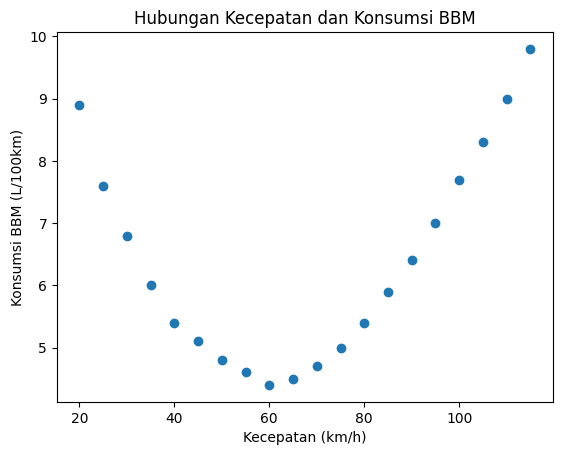

In [ ]:
plt.scatter(data['speed_kmh'], data['fuel_consumption'])
plt.xlabel("Kecepatan (km/h)")
plt.ylabel("Konsumsi BBM (L/100km)")
plt.title("Hubungan Kecepatan dan Konsumsi BBM")
plt.show()

In [ ]:
x = data[['speed_kmh']]
y = data['fuel_consumption']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
poly = PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [ ]:
model = LinearRegression()
model.fit(x_train_poly, y_train)

LinearRegression()

In [ ]:
y_train_pred = model.predict(x_train_poly)
y_test_pred = model.predict(x_test_poly)

In [ ]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("RMSE_Training", rmse_train)
print("RMSE_Testing", rmse_test)

RMSE_Training 0.16936915917924067
RMSE_Testing 0.5614516586136128


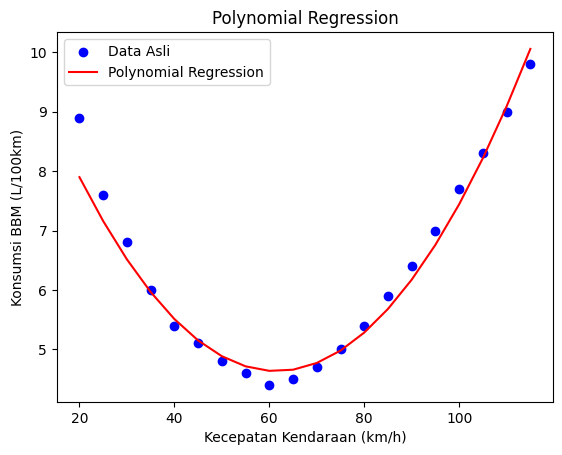

In [ ]:
plt.scatter(x, y, color='blue', label='Data Asli')

x_sorted = np.sort(x.values, axis=0)
x_sorted_poly = poly.fit_transform(x_sorted)

y_sorted_pred = model.predict(x_sorted_poly)

plt.plot(x_sorted, y_sorted_pred, color='red', label='Polynomial Regression')

plt.xlabel("Kecepatan Kendaraan (km/h)")
plt.ylabel("Konsumsi BBM (L/100km)")
plt.title("Polynomial Regression")

plt.legend()

plt.show()

In [ ]:
new_speed = np.array([[120]])
new_speed_poly =  poly.transform(new_speed)
prediction = model.predict(new_speed_poly)
print("Prediksi Konsumsi BBM:", prediction[0])

Prediksi Konsumsi BBM: 11.119871893797004
